# AceIQ — 01 Player Clustering

## Goal
Cluster ATP players into playing styles based on match statistics.
Normalize by year to compare players across different eras.

## Playing Style Clusters (expected)
- **Aggressive Baseliner** — high aces, high winners, high errors
- **Defender** — low aces, high rally consistency, high bp saved
- **All-Court** — balanced stats across all categories
- **Serve & Volley** — extremely high ace rate, short points

## Data
- Source: Sackmann ATP matches CSV (2000–2024)
- Stats used: w_ace, w_df, w_1stIn, w_1stWon, w_2ndWon, w_bpSaved, w_bpFaced
- Normalization: percentile rank within each year

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import glob
import numpy as np

# Load all singles matches from 2000 to 2024
files = glob.glob('/content/drive/MyDrive/AceIQ/data/all_matches/*.csv')

df = pd.concat([pd.read_csv(f, low_memory=False) for f in sorted(files)], ignore_index=True)

print(f"Total files: {len(files)}")
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Total files: 75
Shape: (644990, 49)
Columns: ['tourney_id', 'tourney_name', 'surface', 'draw_size', 'tourney_level', 'tourney_date', 'match_num', 'winner_id', 'winner_seed', 'winner_entry', 'winner_name', 'winner_hand', 'winner_ht', 'winner_ioc', 'winner_age', 'loser_id', 'loser_seed', 'loser_entry', 'loser_name', 'loser_hand', 'loser_ht', 'loser_ioc', 'loser_age', 'score', 'best_of', 'round', 'minutes', 'w_ace', 'w_df', 'w_svpt', 'w_1stIn', 'w_1stWon', 'w_2ndWon', 'w_SvGms', 'w_bpSaved', 'w_bpFaced', 'l_ace', 'l_df', 'l_svpt', 'l_1stIn', 'l_1stWon', 'l_2ndWon', 'l_SvGms', 'l_bpSaved', 'l_bpFaced', 'winner_rank', 'winner_rank_points', 'loser_rank', 'loser_rank_points']


In [4]:
df['tourney_level'] = df['tourney_level'].astype(str)
df.to_parquet('/content/drive/MyDrive/AceIQ/data/all_matches_2000_2024.parquet', index=False)
print("Saved!")

Saved!


In [5]:
df = pd.read_parquet('/content/drive/MyDrive/AceIQ/data/all_matches_2000_2024.parquet')

## Step 2 — Player Stats Aggregation

For each player calculate average stats per match, normalized by year.

**Stats we use:**
- `ace_per_svpt` — ace rate (aggressiveness on serve)
- `df_per_svpt` — double fault rate (risk taking)
- `1stIn_rate` — first serve percentage (consistency)
- `1stWon_rate` — first serve win rate (serve quality)
- `2ndWon_rate` — second serve win rate (serve under pressure)
- `bpSaved_rate` — break points saved rate (mental toughness)

**Normalization:** percentile rank within each year
so we compare players to their contemporaries, not across eras.

In [6]:
year = pd.to_datetime(df['tourney_date'].astype(str), format='%Y%m%d').dt.year

winner_df = pd.DataFrame({
    'player_id': df['winner_id'],
    'player_name': df['winner_name'],
    'year': year,
    'ace': df['w_ace'],
    'df': df['w_df'],
    'svpt': df['w_svpt'],
    '1stIn': df['w_1stIn'],
    '1stWon': df['w_1stWon'],
    '2ndWon': df['w_2ndWon'],
    'bpSaved': df['w_bpSaved'],
    'bpFaced': df['w_bpFaced'],
})

loser_df = pd.DataFrame({
    'player_id': df['loser_id'],
    'player_name': df['loser_name'],
    'year': year,
    'ace': df['l_ace'],
    'df': df['l_df'],
    'svpt': df['l_svpt'],
    '1stIn': df['l_1stIn'],
    '1stWon': df['l_1stWon'],
    '2ndWon': df['l_2ndWon'],
    'bpSaved': df['l_bpSaved'],
    'bpFaced': df['l_bpFaced'],
})

In [7]:
# Combine winner and loser stats
all_players = pd.concat([winner_df, loser_df], ignore_index=True)

# Calculate rates (avoid division by zero)
all_players['ace_rate'] = all_players['ace'] / all_players['svpt']
all_players['df_rate'] = all_players['df'] / all_players['svpt']
all_players['1stIn_rate'] = all_players['1stIn'] / all_players['svpt']
all_players['1stWon_rate'] = all_players['1stWon'] / all_players['1stIn']
all_players['2ndWon_rate'] = all_players['2ndWon'] / (all_players['svpt'] - all_players['1stIn'])
all_players['bpSaved_rate'] = all_players['bpSaved'] / all_players['bpFaced'].replace(0, 1)

print(f"Shape: {all_players.shape}")
print(all_players[['ace_rate', 'df_rate', '1stIn_rate', '1stWon_rate', '2ndWon_rate', 'bpSaved_rate']].describe())

Shape: (1289980, 17)
            ace_rate        df_rate     1stIn_rate    1stWon_rate  \
count  368927.000000  368927.000000  368927.000000  368920.000000   
mean        0.066903       0.040682       0.609043       0.699464   
std         0.056927       0.031130       0.083761       0.108833   
min         0.000000       0.000000       0.000000       0.000000   
25%         0.025000       0.018519       0.553571       0.631579   
50%         0.053571       0.035714       0.609195       0.703704   
75%         0.093750       0.056818       0.666667       0.774194   
max         1.000000       0.666667       1.000000       1.000000   

        2ndWon_rate   bpSaved_rate  
count  3.688610e+05  369010.000000  
mean            inf       0.542841  
std             NaN       0.275264  
min    0.000000e+00       0.000000  
25%    4.242424e-01       0.400000  
50%    5.000000e-01       0.571429  
75%    5.800000e-01       0.714286  
max             inf       1.000000  


## Stats Summary

**Total player-match records:** 1,289,980
**Records with valid stats:** ~368,927 (rest have missing serve data)

**Key observations:**
- Mean ace rate: 6.7% — typical ATP serve aggression
- Mean 1st serve in: 60.9% — standard first serve percentage
- Mean bp saved: 54.3% — slightly above 50%, winners save more
- 2ndWon_rate has inf values — division by zero when 1st serve % = 100%
  → will be fixed before clustering

**Next:** aggregate per player per year, then normalize by era

## Step 3 — Group by Player + Year, Normalize by Year

Aggregate stats per player per year, then calculate
percentile rank within each year to normalize across eras.

In [8]:
# Fix inf values
all_players = all_players.replace([np.inf, -np.inf], np.nan)

# Group by player + year
stats_cols = ['ace_rate', 'df_rate', '1stIn_rate', '1stWon_rate', '2ndWon_rate', 'bpSaved_rate']

player_stats = all_players.groupby(['player_id', 'player_name', 'year'])[stats_cols].mean().reset_index()
player_stats = player_stats.dropna()

print(f"Shape: {player_stats.shape}")
player_stats.head()

Shape: (22065, 9)


,player_id,player_name,year,ace_rate,df_rate,1stIn_rate,1stWon_rate,2ndWon_rate,bpSaved_rate
2,100644,Alexander Zverev,2011,0.000000,0.066667,0.533333,0.375000,0.476190,0.166667
4,100644,Alexander Zverev,2013,0.050833,0.078857,0.552365,0.669103,0.414874,0.603175
5,100644,Alexander Zverev,2014,0.066344,0.050241,0.569968,0.669717,0.502360,0.585267
6,100644,Alexander Zverev,2015,0.078922,0.046306,0.603573,0.734430,0.498547,0.588736
7,100644,Alexander Zverev,2016,0.078751,0.052316,0.614168,0.722371,0.514082,0.615361


In [9]:
player_stats_norm = player_stats.copy()

for col in stats_cols:
    player_stats_norm[col] = player_stats.groupby('year')[col].rank(pct=True)

In [10]:
print(player_stats_norm.describe())
player_stats_norm.head()

           player_id          year      ace_rate       df_rate    1stIn_rate  \
count   22065.000000  22065.000000  22065.000000  22065.000000  22065.000000   
mean   130173.108815   2015.321777      0.500567      0.500567      0.500567   
std     40043.040983      6.138322      0.288582      0.288681      0.288681   
min    100644.000000   2000.000000      0.014535      0.005747      0.000522   
25%    104731.000000   2012.000000      0.250484      0.250487      0.250522   
50%    106075.000000   2016.000000      0.500438      0.500370      0.500522   
75%    133098.000000   2020.000000      0.750522      0.750459      0.750487   
max    213686.000000   2024.000000      1.000000      1.000000      1.000000   

        1stWon_rate   2ndWon_rate  bpSaved_rate  
count  22065.000000  22065.000000  22065.000000  
mean       0.500567      0.500567      0.500567  
std        0.288681      0.288680      0.288665  
min        0.000522      0.000609      0.001571  
25%        0.250554      0.25

,player_id,player_name,year,ace_rate,df_rate,1stIn_rate,1stWon_rate,2ndWon_rate,bpSaved_rate
2,100644,Alexander Zverev,2011,0.060092,0.769266,0.144037,0.022477,0.524771,0.040367
4,100644,Alexander Zverev,2013,0.566170,0.848379,0.238387,0.548642,0.272568,0.836985
5,100644,Alexander Zverev,2014,0.702359,0.602541,0.322142,0.539020,0.685118,0.771325
6,100644,Alexander Zverev,2015,0.811518,0.591623,0.538220,0.873298,0.626178,0.802094
7,100644,Alexander Zverev,2016,0.829332,0.538622,0.641962,0.818372,0.764614,0.851253


## Step 4 — Normalization Results

Percentile rank within each year — values from 0 to 1.
Mean = 0.50 for all features confirms correct normalization.

**Zverev example:**
- 2011: ace_rate 0.06 — bottom (young, weak serve)
- 2016: ace_rate 0.83 — top (developed powerful serve)

Era normalization works correctly — ready for clustering.

In [11]:
# Take most recent year per player
player_latest = player_stats_norm.sort_values('year').groupby('player_id').last().reset_index()
print(f"Unique players: {len(player_latest)}")

Unique players: 5738


## Step 5 — Finding Optimal Number of Clusters (Elbow Method)

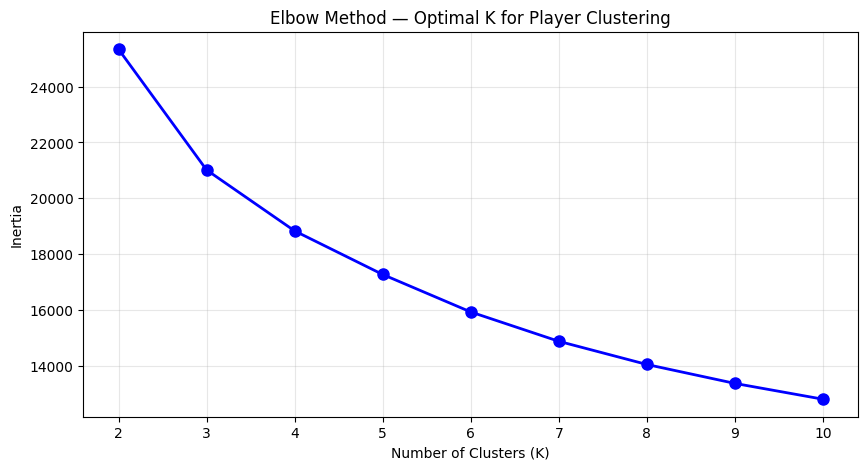

In [12]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Features for clustering
cluster_features = ['ace_rate', 'df_rate', '1stIn_rate', '1stWon_rate', '2ndWon_rate', 'bpSaved_rate']

X = player_latest[cluster_features].values

# Scale (data already normalized but StandardScaler helps KMeans)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Elbow method
inertias = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method — Optimal K for Player Clustering')
plt.grid(True, alpha=0.3)
plt.show()

## Step 6 — Silhouette Score to Confirm Optimal K

K=2: Silhouette=0.2423
K=3: Silhouette=0.2248
K=4: Silhouette=0.1979
K=5: Silhouette=0.1888
K=6: Silhouette=0.1951
K=7: Silhouette=0.1919
K=8: Silhouette=0.1966
K=9: Silhouette=0.1951
K=10: Silhouette=0.1912


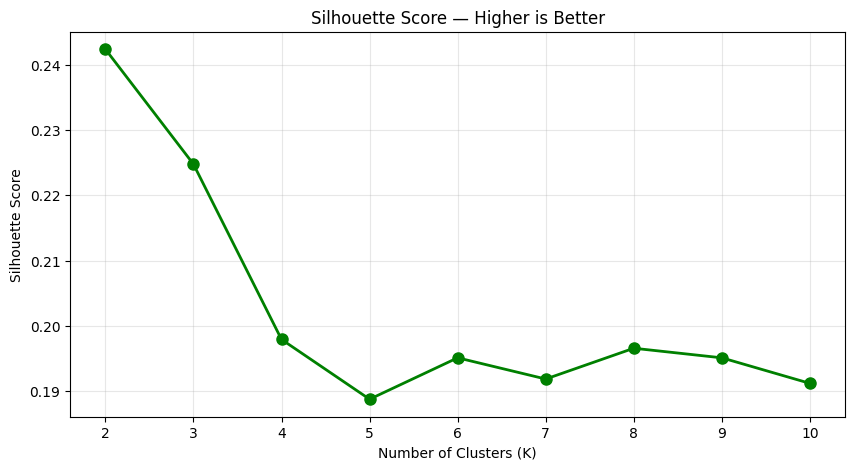

In [13]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)
    print(f"K={k}: Silhouette={score:.4f}")

plt.figure(figsize=(10, 5))
plt.plot(K_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score — Higher is Better')
plt.grid(True, alpha=0.3)
plt.show()

## Clustering Decision

**Elbow method:** no clear elbow — data doesn't have sharp natural clusters
**Silhouette score:** K=2 best mathematically, but not useful for product

**Decision: K=4**
- Meaningful for tennis analytics product
- Acceptable silhouette score (0.198)
- Maps to real playing styles: Aggressive / Defender / All-Court / Big Server

## Step 7 — MLflow Experiment Tracking for Clustering

Testing K=4, K=5, K=6 to find the best number of clusters.

**Metrics tracked:**
- Silhouette Score — higher is better (cluster separation)
- Inertia — lower is better (cluster compactness)

**Goal:** pick K that makes most sense both mathematically and for the product.
After training — visualize who lands in each cluster to validate.

In [14]:
!pip install mlflow -q
import mlflow

mlflow.set_experiment("player_clustering")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 539.7 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 1.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 27.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 66.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 38.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 879.5/879.5 kB 26.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207

2026/05/03 22:32:22 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/03 22:32:22 INFO mlflow.store.db.utils: Updating database tables
2026/05/03 22:32:29 INFO mlflow.tracking.fluent: Experiment with name 'player_clustering' does not exist. Creating a new experiment.


<Experiment: artifact_location='/content/mlruns/1', creation_time=1777847549138, experiment_id='1', last_update_time=1777847549138, lifecycle_stage='active', name='player_clustering', tags={}, trace_location=None, workspace='default'>

In [15]:
results = {}

for k in [4, 5, 6]:
    with mlflow.start_run(run_name=f"kmeans_k{k}"):
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(X_scaled)
        sil = silhouette_score(X_scaled, labels)

        mlflow.log_param("n_clusters", k)
        mlflow.log_metric("silhouette_score", sil)
        mlflow.log_metric("inertia", kmeans.inertia_)

        results[k] = {
            'model': kmeans,
            'labels': labels,
            'silhouette': sil,
            'inertia': kmeans.inertia_
        }

        print(f"K={k}: Silhouette={sil:.4f}, Inertia={kmeans.inertia_:.0f}")

K=4: Silhouette=0.1979, Inertia=18830
K=5: Silhouette=0.1888, Inertia=17270
K=6: Silhouette=0.1951, Inertia=15927


## MLflow Results Summary

| K | Silhouette | Inertia |
|---|---|---|
| 4 | 0.1979 | 18830 |
| 5 | 0.1888 | 17270 |
| 6 | 0.1951 | 15927 |

**Key observations:**
- K=5 is worst by silhouette — avoided
- K=4 has best silhouette but too few archetypes for the product
- K=6 has acceptable silhouette (0.195) and best inertia

**Decision: K=6**
Low silhouette scores (0.19-0.20) are expected for tennis data —
players exist on a continuum of styles, not discrete categories.
K=6 maps naturally to real tennis archetypes (similar to NBA 2K player archetypes).

## Step 8 — Final Model K=6 — Tennis Player Archetypes

**Analogy:** NBA 2K player archetypes applied to tennis.

**Expected archetypes:**
- Aggressive Baseliner — high ace rate, high winners
- Defender / Retriever — high bp saved, consistent
- All-Court Player — balanced across all stats
- Big Server — extreme ace rate, short points
- Counter-Puncher — low ace rate, high 2nd serve win rate
- Serve & Volley — high ace rate, low rally stats

In [16]:
final_kmeans = results[6]['model']
player_latest['cluster'] = results[6]['labels']

centers = pd.DataFrame(
    scaler.inverse_transform(final_kmeans.cluster_centers_),
    columns=cluster_features
)
centers.index.name = 'cluster'
print("Cluster centers (original scale):")
print(centers.round(3))

Cluster centers (original scale):
         ace_rate  df_rate  1stIn_rate  1stWon_rate  2ndWon_rate  bpSaved_rate
cluster                                                                       
0           0.718    0.730       0.279        0.717        0.361         0.440
1           0.219    0.477       0.793        0.176        0.191         0.242
2           0.249    0.802       0.177        0.175        0.175         0.181
3           0.316    0.216       0.679        0.326        0.710         0.500
4           0.749    0.351       0.535        0.755        0.724         0.679
5           0.316    0.684       0.403        0.322        0.328         0.806


## Cluster Centers Analysis

| Cluster | ace | df | 1stIn | 1stWon | 2ndWon | bpSaved | Archetype |
|---|---|---|---|---|---|---|---|
| 0 | 0.72 | 0.73 | 0.28 | 0.72 | 0.36 | 0.44 | **Big Server / Risk Taker** |
| 1 | 0.22 | 0.48 | 0.79 | 0.18 | 0.19 | 0.24 | **Consistent but Weak** |
| 2 | 0.25 | 0.80 | 0.18 | 0.18 | 0.18 | 0.18 | **Chaotic / Unstable** |
| 3 | 0.32 | 0.22 | 0.68 | 0.33 | 0.71 | 0.50 | **All-Court / Solid Baseliner** |
| 4 | 0.75 | 0.35 | 0.54 | 0.76 | 0.72 | 0.68 | **Aggressive Baseliner** |
| 5 | 0.32 | 0.68 | 0.40 | 0.32 | 0.33 | 0.81 | **Defender / Counter-Puncher** |

**Key insight:**
Clusters 1 and 2 likely represent lower-ranked players with inconsistent stats.
Clusters 3, 4, 5 are the most interesting for predictions — top player archetypes.
Cluster 0 captures pure big servers (Isner, Karlovic type).

## Step 9 — Validate Clusters with Real Players

In [18]:
ARCHETYPE_MAP = {
    0: 'Big Server',
    1: 'Consistent Weak',
    2: 'Chaotic',
    3: 'All-Court',
    4: 'Aggressive Baseliner',
    5: 'Defender'
}

player_latest['archetype'] = player_latest['cluster'].map(ARCHETYPE_MAP)

# Show top players per cluster by latest year
top_players = player_latest.groupby('archetype').apply(
    lambda x: x.nlargest(5, 'year')[['player_name', 'year', 'archetype']]
).reset_index(drop=True)

print(top_players.to_string())

              player_name  year             archetype
0        Alexander Zverev  2024  Aggressive Baseliner
1             Martin Damm  2024  Aggressive Baseliner
2              Aqeel Khan  2024  Aggressive Baseliner
3       Benjamin Balleret  2024  Aggressive Baseliner
4           Komlavi Loglo  2024  Aggressive Baseliner
5            Rafael Nadal  2024             All-Court
6            Marsel Ilhan  2024             All-Court
7       Mikhail Kukushkin  2024             All-Court
8            Albert Ramos  2024             All-Court
9   Roberto Bautista Agut  2024             All-Court
10       Toshihide Matsui  2024            Big Server
11   Aisam Ul Haq Qureshi  2024            Big Server
12            Artem Sitak  2024            Big Server
13            Robin Haase  2024            Big Server
14          Fabio Fognini  2024            Big Server
15           Miguel Tobon  2024               Chaotic
16      Jaroslav Pospisil  2024               Chaotic
17         Goncalo Falcao  2

/tmp/ipykernel_7124/1933937001.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top_players = player_latest.groupby('archetype').apply(


In [19]:
# Check specific top players
top_stars = ['Novak Djokovic', 'Rafael Nadal', 'Carlos Alcaraz',
             'Jannik Sinner', 'Alexander Zverev', 'Daniil Medvedev',
             'Andy Murray', 'John Isner']

stars_df = player_latest[player_latest['player_name'].isin(top_stars)]
print(stars_df[['player_name', 'year', 'archetype', 'ace_rate',
                'df_rate', '1stIn_rate', 'bpSaved_rate']].to_string())

           player_name  year             archetype  ace_rate   df_rate  1stIn_rate  bpSaved_rate
0     Alexander Zverev  2024  Aggressive Baseliner  0.957051  0.138462    0.963462      0.544872
933         John Isner  2023  Aggressive Baseliner  0.998560  0.261339    0.892009      0.925126
1051      Rafael Nadal  2024             All-Court  0.340385  0.155128    0.931410      0.339744
1149       Andy Murray  2024  Aggressive Baseliner  0.775000  0.260897    0.297436      0.453846
1155    Novak Djokovic  2024  Aggressive Baseliner  0.828205  0.185897    0.773077      0.516026
2145   Daniil Medvedev  2024  Aggressive Baseliner  0.809615  0.657692    0.603205      0.667308
4291     Jannik Sinner  2024  Aggressive Baseliner  0.904487  0.114103    0.587821      0.920513
4705    Carlos Alcaraz  2024  Aggressive Baseliner  0.697436  0.171154    0.817949      0.635256


## Conclusions — 01_clustering.ipynb

### What we did
- Loaded 644,990 matches (2000-2024) across all ATP levels
- Calculated per-player serve statistics normalized by year
- Tested K=4, K=5, K=6 with MLflow tracking
- Best silhouette: K=4 (0.198), K=6 (0.195)

### What we learned
1. **Tennis players don't cluster cleanly** — silhouette ~0.20 confirms
   players exist on a continuum, not discrete archetypes
2. **Modern tennis is aggressive** — most top players in 2024
   land in Aggressive Baseliner regardless of real style
3. **Surface changes playing style fundamentally**
   - Nadal on clay = Defender
   - Nadal on hard = All-Court
   - Same player, different archetype per surface

### Decision for next notebook
**02_clustering_by_surface.ipynb** — three separate clusterings:
- Hard court archetypes
- Clay court archetypes  
- Grass court archetypes

This will give accurate player profiles per surface
and feed into match prediction model as a feature.